In [21]:
!pip -q install tensorflow tensorflow_hub librosa scikit-learn pandas numpy soundfile

In [22]:
import os
import gc
import math
import json
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import librosa
import soundfile as sf
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
import tensorflow_hub as hub
import joblib

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TF version:", tf.__version__)
print("Num GPUs:", len(tf.config.list_physical_devices("GPU")))

TF version: 2.19.0
Num GPUs: 2


In [23]:
def find_first_existing(candidates):
    for p in candidates:
        if p is not None and os.path.exists(p):
            return p
    return None

In [24]:
ESC50_META = find_first_existing([
    "/kaggle/input/datasets/niranjankn/esc50/ESC-50-master/meta/esc50.csv"
    
])

ESC50_AUDIO_DIR = find_first_existing([
    "/kaggle/input/datasets/niranjankn/esc50/ESC-50-master/audio",

])

URBAN_META = find_first_existing([
    "/kaggle/input/datasets/chrisfilo/urbansound8k/UrbanSound8K.csv",
    
])

URBAN_AUDIO_ROOT = find_first_existing([
    "/kaggle/input/datasets/chrisfilo/urbansound8k",
    
])

SCREAM_ROOT = find_first_existing([
    "/kaggle/input/datasets/whats2000/human-screaming-detection-dataset",
    
])

EXTRA_SCREAM_ROOT = find_first_existing([
    "/kaggle/input/datasets/aananehsansiam/audio-dataset-of-scream-and-non-scream/Converted_Separately",
    
])

PREV_MODEL_PATH = find_first_existing([
    "/kaggle/input/datasets/sadiamostafa/screamm/best_finetuned_with_scream.keras",
    
    
])

print("ESC50_META         :", ESC50_META)
print("ESC50_AUDIO_DIR    :", ESC50_AUDIO_DIR)
print("URBAN_META         :", URBAN_META)
print("URBAN_AUDIO_ROOT   :", URBAN_AUDIO_ROOT)
print("SCREAM_ROOT        :", SCREAM_ROOT)
print("EXTRA_SCREAM_ROOT  :", EXTRA_SCREAM_ROOT)
print("PREV_MODEL_PATH    :", PREV_MODEL_PATH, os.path.exists(PREV_MODEL_PATH) if PREV_MODEL_PATH else False)

ESC50_META         : /kaggle/input/datasets/niranjankn/esc50/ESC-50-master/meta/esc50.csv
ESC50_AUDIO_DIR    : /kaggle/input/datasets/niranjankn/esc50/ESC-50-master/audio
URBAN_META         : /kaggle/input/datasets/chrisfilo/urbansound8k/UrbanSound8K.csv
URBAN_AUDIO_ROOT   : /kaggle/input/datasets/chrisfilo/urbansound8k
SCREAM_ROOT        : /kaggle/input/datasets/whats2000/human-screaming-detection-dataset
EXTRA_SCREAM_ROOT  : /kaggle/input/datasets/aananehsansiam/audio-dataset-of-scream-and-non-scream/Converted_Separately
PREV_MODEL_PATH    : /kaggle/input/datasets/sadiamostafa/screamm/best_finetuned_with_scream.keras True


In [25]:
LABEL_NORMAL = 0
LABEL_EMERGENCY = 1

SR = 16000

ESC50_EMERGENCY = {
    "crying_baby",
    "siren",
    "glass_breaking",
    "door_wood_knock",
    "door_wood_creaks",
    "can_opening"
}

ESC50_NORMAL = {
    "clock_tick",
    "rain",
    "keyboard_typing",
    "vacuum_cleaner",
    "footsteps",
    "brushing_teeth",
    "washing_machine",
    "wind",
    "pouring_water",
    "crickets"
}

URBAN_EMERGENCY = {
    "siren",
    "gun_shot",
    "jackhammer"
}

URBAN_NORMAL = {
    "air_conditioner",
    "children_playing",
    "dog_bark",
    "drilling",
    "engine_idling",
    "street_music"
}

In [26]:
yamnet = hub.load("https://tfhub.dev/google/yamnet/1")
print("YAMNet loaded")

YAMNet loaded


In [27]:
def load_wav_16k_mono(path, sr=SR):
    try:
        wav, orig_sr = librosa.load(path, sr=sr, mono=True)
        if wav is None or len(wav) == 0:
            return None
        wav = wav.astype(np.float32)
        wav = np.clip(wav, -1.0, 1.0)
        return wav
    except Exception:
        return None


def augment_waveform(wav, sr=SR):
    x = wav.copy()

    if np.random.rand() < 0.5:
        noise = np.random.normal(0, 0.003, size=len(x)).astype(np.float32)
        x = x + noise

    if np.random.rand() < 0.4:
        gain = np.random.uniform(0.8, 1.2)
        x = x * gain

    if np.random.rand() < 0.3:
        shift = int(np.random.uniform(-0.15, 0.15) * sr)
        x = np.roll(x, shift)

    if np.random.rand() < 0.3:
        rate = np.random.uniform(0.95, 1.05)
        try:
            x = librosa.effects.time_stretch(x, rate=rate)
        except Exception:
            pass

        if len(x) > len(wav):
            x = x[:len(wav)]
        else:
            x = np.pad(x, (0, max(0, len(wav) - len(x))))

    x = np.clip(x, -1.0, 1.0).astype(np.float32)
    return x

In [28]:
def extract_embeddings_from_wav(wav):
    scores, embeddings, spectrogram = yamnet(wav)
    return embeddings.numpy()


def extract_clip_embeddings(path, train_aug=False, n_aug=1):
    wav = load_wav_16k_mono(path, sr=SR)
    if wav is None:
        return []

    out = []

    emb = extract_embeddings_from_wav(wav)
    if emb is not None and len(emb) > 0:
        out.append(emb)

    if train_aug and n_aug > 0:
        for _ in range(n_aug):
            wav_aug = augment_waveform(wav, sr=SR)
            emb_aug = extract_embeddings_from_wav(wav_aug)
            if emb_aug is not None and len(emb_aug) > 0:
                out.append(emb_aug)

    return out

In [29]:
def gather_audio_files(folder):
    paths = []
    for root, dirs, files in os.walk(folder):
        for f in files:
            if f.lower().endswith((".wav", ".mp3", ".flac", ".ogg", ".m4a")):
                paths.append(os.path.join(root, f))
    return sorted(paths)

In [30]:
def build_esc50_df():
    if ESC50_META is None or ESC50_AUDIO_DIR is None:
        return pd.DataFrame()

    meta = pd.read_csv(ESC50_META)
    rows = []

    for _, r in meta.iterrows():
        category = str(r["category"]).strip()

        if category in ESC50_EMERGENCY:
            label = LABEL_EMERGENCY
        elif category in ESC50_NORMAL:
            label = LABEL_NORMAL
        else:
            continue

        fold = int(r["fold"])
        if fold in [1, 2, 3]:
            split = "train"
        elif fold == 4:
            split = "val"
        else:
            split = "test"

        rows.append({
            "source": "esc50",
            "path": os.path.join(ESC50_AUDIO_DIR, r["filename"]),
            "clip_id": f"esc50_{r['filename']}",
            "orig_class": category,
            "label": label,
            "split": split,
        })

    return pd.DataFrame(rows)

esc_df = build_esc50_df()
print("ESC rows:", len(esc_df))
display(esc_df.head())

ESC rows: 640


,source,path,clip_id,orig_class,label,split
0,esc50,/kaggle/input/datasets/niranjankn/esc50/ESC-50...,esc50_1-100210-A-36.wav,vacuum_cleaner,0,train
1,esc50,/kaggle/input/datasets/niranjankn/esc50/ESC-50...,esc50_1-100210-B-36.wav,vacuum_cleaner,0,train
2,esc50,/kaggle/input/datasets/niranjankn/esc50/ESC-50...,esc50_1-101336-A-30.wav,door_wood_knock,1,train
3,esc50,/kaggle/input/datasets/niranjankn/esc50/ESC-50...,esc50_1-101404-A-34.wav,can_opening,1,train
4,esc50,/kaggle/input/datasets/niranjankn/esc50/ESC-50...,esc50_1-103995-A-30.wav,door_wood_knock,1,train


In [31]:
def build_urban_df():
    if URBAN_META is None or URBAN_AUDIO_ROOT is None:
        return pd.DataFrame()

    meta = pd.read_csv(URBAN_META)
    rows = []

    for _, r in meta.iterrows():
        cls = str(r["class"]).strip()

        if cls in URBAN_EMERGENCY:
            label = LABEL_EMERGENCY
        elif cls in URBAN_NORMAL:
            label = LABEL_NORMAL
        else:
            continue

        fold = int(r["fold"])
        if fold in [1, 2, 3, 4, 5, 6, 7, 8]:
            split = "train"
        elif fold == 9:
            split = "val"
        else:
            split = "test"

        rows.append({
            "source": "urbansound8k",
            "path": os.path.join(URBAN_AUDIO_ROOT, f"fold{fold}", r["slice_file_name"]),
            "clip_id": f"urban_fold{fold}_{r['slice_file_name']}",
            "orig_class": cls,
            "label": label,
            "split": split,
        })

    return pd.DataFrame(rows)

urban_df = build_urban_df()
print("Urban rows:", len(urban_df))
display(urban_df.head())

Urban rows: 8303


,source,path,clip_id,orig_class,label,split
0,urbansound8k,/kaggle/input/datasets/chrisfilo/urbansound8k/...,urban_fold5_100032-3-0-0.wav,dog_bark,0,train
1,urbansound8k,/kaggle/input/datasets/chrisfilo/urbansound8k/...,urban_fold5_100263-2-0-117.wav,children_playing,0,train
2,urbansound8k,/kaggle/input/datasets/chrisfilo/urbansound8k/...,urban_fold5_100263-2-0-121.wav,children_playing,0,train
3,urbansound8k,/kaggle/input/datasets/chrisfilo/urbansound8k/...,urban_fold5_100263-2-0-126.wav,children_playing,0,train
4,urbansound8k,/kaggle/input/datasets/chrisfilo/urbansound8k/...,urban_fold5_100263-2-0-137.wav,children_playing,0,train


In [32]:
def build_scream_df():
    if SCREAM_ROOT is None:
        return pd.DataFrame()

    scream_dir = os.path.join(SCREAM_ROOT, "Screaming")
    nonscream_dir = os.path.join(SCREAM_ROOT, "NotScreaming")

    scream_files = gather_audio_files(scream_dir) if os.path.isdir(scream_dir) else []
    nonscream_files = gather_audio_files(nonscream_dir) if os.path.isdir(nonscream_dir) else []

    rows = []

    def assign_split(i, total):
        frac = i / max(total, 1)
        if frac < 0.80:
            return "train"
        elif frac < 0.90:
            return "val"
        else:
            return "test"

    for i, p in enumerate(scream_files):
        rows.append({
            "source": "human_scream_dataset",
            "path": p,
            "clip_id": f"scream_{os.path.basename(p)}_{i}",
            "orig_class": "scream",
            "label": LABEL_EMERGENCY,
            "split": assign_split(i, len(scream_files)),
        })

    for i, p in enumerate(nonscream_files):
        rows.append({
            "source": "human_scream_dataset",
            "path": p,
            "clip_id": f"nonscream_{os.path.basename(p)}_{i}",
            "orig_class": "not_screaming",
            "label": LABEL_NORMAL,
            "split": assign_split(i, len(nonscream_files)),
        })

    return pd.DataFrame(rows)

scream_df = build_scream_df()
print("Human scream rows:", len(scream_df))
if len(scream_df):
    print(scream_df["orig_class"].value_counts())
display(scream_df.head())

Human scream rows: 3493
orig_class
not_screaming    2631
scream            862
Name: count, dtype: int64


,source,path,clip_id,orig_class,label,split
0,human_scream_dataset,/kaggle/input/datasets/whats2000/human-screami...,scream_---1_cCGK4M_out.wav_0,scream,1,train
1,human_scream_dataset,/kaggle/input/datasets/whats2000/human-screami...,scream_-20uudT97E0_out.wav_1,scream,1,train
2,human_scream_dataset,/kaggle/input/datasets/whats2000/human-screami...,scream_-2yygHLdpXc_out.wav_2,scream,1,train
3,human_scream_dataset,/kaggle/input/datasets/whats2000/human-screami...,scream_-3bGlOhRkAo_out.wav_3,scream,1,train
4,human_scream_dataset,/kaggle/input/datasets/whats2000/human-screami...,scream_-4pUrlMafww_out.wav_4,scream,1,train


In [33]:
if EXTRA_SCREAM_ROOT is not None:
    for root, dirs, files in os.walk(EXTRA_SCREAM_ROOT):
        print("ROOT :", root)
        print("DIRS :", dirs[:10])
        print("FILES:", files[:10])
        print("-" * 80)

ROOT : /kaggle/input/datasets/aananehsansiam/audio-dataset-of-scream-and-non-scream/Converted_Separately
DIRS : ['scream', 'non_scream']
FILES: []
--------------------------------------------------------------------------------
ROOT : /kaggle/input/datasets/aananehsansiam/audio-dataset-of-scream-and-non-scream/Converted_Separately/scream
DIRS : []
FILES: ['611.wav', '364.wav', '367.wav', '116.wav', '1490.wav', '374.wav', '1359.wav', '485.wav', '456.wav', '626.wav']
--------------------------------------------------------------------------------
ROOT : /kaggle/input/datasets/aananehsansiam/audio-dataset-of-scream-and-non-scream/Converted_Separately/non_scream
DIRS : []
FILES: ['611.wav', '364.wav', '367.wav', '116.wav', '1490.wav', '374.wav', '1359.wav', '485.wav', '456.wav', '626.wav']
--------------------------------------------------------------------------------


In [34]:
def build_extra_scream_df():
    if EXTRA_SCREAM_ROOT is None or not os.path.isdir(EXTRA_SCREAM_ROOT):
        print("EXTRA_SCREAM_ROOT not found:", EXTRA_SCREAM_ROOT)
        return pd.DataFrame()

    base_dir = os.path.join(EXTRA_SCREAM_ROOT, "Converted_Separately")
    scream_dir = os.path.join(base_dir, "scream")
    nonscream_dir = os.path.join(base_dir, "non_scream")

    print("Base dir      :", base_dir)
    print("Scream dir    :", scream_dir, "| exists:", os.path.isdir(scream_dir))
    print("Non-scream dir:", nonscream_dir, "| exists:", os.path.isdir(nonscream_dir))

    scream_files = sorted(gather_audio_files(scream_dir)) if os.path.isdir(scream_dir) else []
    nonscream_files = sorted(gather_audio_files(nonscream_dir)) if os.path.isdir(nonscream_dir) else []

    rows = []

    def assign_split(i, total):
        frac = i / max(total, 1)
        if frac < 0.80:
            return "train"
        elif frac < 0.90:
            return "val"
        else:
            return "test"

    for i, p in enumerate(scream_files):
        rows.append({
            "source": "extra_scream_dataset",
            "path": p,
            "clip_id": f"extra_scream_{i}",
            "orig_class": "scream",
            "label": LABEL_EMERGENCY,
            "split": assign_split(i, len(scream_files)),
        })

    for i, p in enumerate(nonscream_files):
        rows.append({
            "source": "extra_scream_dataset",
            "path": p,
            "clip_id": f"extra_nonscream_{i}",
            "orig_class": "non_scream",
            "label": LABEL_NORMAL,
            "split": assign_split(i, len(nonscream_files)),
        })

    df = pd.DataFrame(rows).reset_index(drop=True)
    return df


extra_scream_df = build_extra_scream_df()

print("Extra scream rows:", len(extra_scream_df))
if len(extra_scream_df) > 0:
    print("\nClass counts:")
    print(extra_scream_df["orig_class"].value_counts())
    print("\nSplit counts:")
    print(extra_scream_df["split"].value_counts())
    display(extra_scream_df.head())
else:
    print("No files found in extra scream dataset.")

Base dir      : /kaggle/input/datasets/aananehsansiam/audio-dataset-of-scream-and-non-scream/Converted_Separately/Converted_Separately
Scream dir    : /kaggle/input/datasets/aananehsansiam/audio-dataset-of-scream-and-non-scream/Converted_Separately/Converted_Separately/scream | exists: False
Non-scream dir: /kaggle/input/datasets/aananehsansiam/audio-dataset-of-scream-and-non-scream/Converted_Separately/Converted_Separately/non_scream | exists: False
Extra scream rows: 0
No files found in extra scream dataset.


In [35]:
def build_extra_scream_df():
    if EXTRA_SCREAM_ROOT is None or not os.path.isdir(EXTRA_SCREAM_ROOT):
        print("EXTRA_SCREAM_ROOT not found:", EXTRA_SCREAM_ROOT)
        return pd.DataFrame()

    scream_dir = os.path.join(EXTRA_SCREAM_ROOT, "scream")
    nonscream_dir = os.path.join(EXTRA_SCREAM_ROOT, "non_scream")

    print("Scream dir    :", scream_dir, "| exists:", os.path.isdir(scream_dir))
    print("Non-scream dir:", nonscream_dir, "| exists:", os.path.isdir(nonscream_dir))

    scream_files = sorted(gather_audio_files(scream_dir)) if os.path.isdir(scream_dir) else []
    nonscream_files = sorted(gather_audio_files(nonscream_dir)) if os.path.isdir(nonscream_dir) else []

    rows = []

    def assign_split(i, total):
        frac = i / max(total, 1)
        if frac < 0.80:
            return "train"
        elif frac < 0.90:
            return "val"
        else:
            return "test"

    for i, p in enumerate(scream_files):
        rows.append({
            "source": "extra_scream_dataset",
            "path": p,
            "clip_id": f"extra_scream_{i}",
            "orig_class": "scream",
            "label": LABEL_EMERGENCY,
            "split": assign_split(i, len(scream_files)),
        })

    for i, p in enumerate(nonscream_files):
        rows.append({
            "source": "extra_scream_dataset",
            "path": p,
            "clip_id": f"extra_nonscream_{i}",
            "orig_class": "non_scream",
            "label": LABEL_NORMAL,
            "split": assign_split(i, len(nonscream_files)),
        })

    df = pd.DataFrame(rows).reset_index(drop=True)
    return df


extra_scream_df = build_extra_scream_df()

print("Extra scream rows:", len(extra_scream_df))
if len(extra_scream_df) > 0:
    print("\nClass counts:")
    print(extra_scream_df["orig_class"].value_counts())
    print("\nSplit counts:")
    print(extra_scream_df["split"].value_counts())
    display(extra_scream_df.head())
else:
    print("No files found in extra scream dataset.")

Scream dir    : /kaggle/input/datasets/aananehsansiam/audio-dataset-of-scream-and-non-scream/Converted_Separately/scream | exists: True
Non-scream dir: /kaggle/input/datasets/aananehsansiam/audio-dataset-of-scream-and-non-scream/Converted_Separately/non_scream | exists: True
Extra scream rows: 3128

Class counts:
orig_class
scream        1583
non_scream    1545
Name: count, dtype: int64

Split counts:
split
train    2503
val       313
test      312
Name: count, dtype: int64


,source,path,clip_id,orig_class,label,split
0,extra_scream_dataset,/kaggle/input/datasets/aananehsansiam/audio-da...,extra_scream_0,scream,1,train
1,extra_scream_dataset,/kaggle/input/datasets/aananehsansiam/audio-da...,extra_scream_1,scream,1,train
2,extra_scream_dataset,/kaggle/input/datasets/aananehsansiam/audio-da...,extra_scream_2,scream,1,train
3,extra_scream_dataset,/kaggle/input/datasets/aananehsansiam/audio-da...,extra_scream_3,scream,1,train
4,extra_scream_dataset,/kaggle/input/datasets/aananehsansiam/audio-da...,extra_scream_4,scream,1,train


In [36]:
parts = [esc_df, urban_df, scream_df, extra_scream_df]
parts = [x for x in parts if x is not None and len(x) > 0]

df = pd.concat(parts, ignore_index=True)
df = df.drop_duplicates(subset=["path"]).reset_index(drop=True)

print("Total rows:", len(df))
print(df["split"].value_counts())
print(df["label"].value_counts())
print(df["source"].value_counts())

display(df.sample(min(10, len(df)), random_state=SEED))

Total rows: 15564
split
train    12397
test      1593
val       1574
Name: count, dtype: int64
label
0    10576
1     4988
Name: count, dtype: int64
source
urbansound8k            8303
human_scream_dataset    3493
extra_scream_dataset    3128
esc50                    640
Name: count, dtype: int64


,source,path,clip_id,orig_class,label,split
99,esc50,/kaggle/input/datasets/niranjankn/esc50/ESC-50...,esc50_1-68670-A-34.wav,can_opening,1,train
11430,human_scream_dataset,/kaggle/input/datasets/whats2000/human-screami...,nonscream__4VCZp20FfM_out.wav_1625,not_screaming,0,train
4649,urbansound8k,/kaggle/input/datasets/chrisfilo/urbansound8k/...,urban_fold10_178826-2-0-14.wav,children_playing,0,test
1944,urbansound8k,/kaggle/input/datasets/chrisfilo/urbansound8k/...,urban_fold3_13230-0-0-22.wav,air_conditioner,0,train
3025,urbansound8k,/kaggle/input/datasets/chrisfilo/urbansound8k/...,urban_fold8_157649-3-1-1.wav,dog_bark,0,train
3519,urbansound8k,/kaggle/input/datasets/chrisfilo/urbansound8k/...,urban_fold10_162134-7-17-4.wav,jackhammer,1,test
1617,urbansound8k,/kaggle/input/datasets/chrisfilo/urbansound8k/...,urban_fold5_121286-0-0-6.wav,air_conditioner,0,train
14983,extra_scream_dataset,/kaggle/input/datasets/aananehsansiam/audio-da...,extra_nonscream_964,non_scream,0,train
1768,urbansound8k,/kaggle/input/datasets/chrisfilo/urbansound8k/...,urban_fold3_12647-3-0-0.wav,dog_bark,0,train
11804,human_scream_dataset,/kaggle/input/datasets/whats2000/human-screami...,nonscream_iQAXwX28LLw_out.wav_1999,not_screaming,0,train


In [37]:
train_df = df[df["split"] == "train"].reset_index(drop=True)
val_df   = df[df["split"] == "val"].reset_index(drop=True)
test_df  = df[df["split"] == "test"].reset_index(drop=True)

print("Train:", len(train_df))
print("Val  :", len(val_df))
print("Test :", len(test_df))

Train: 12397
Val  : 1574
Test : 1593


In [38]:
def build_frame_dataset(split_df, train_aug=False, n_aug=1):
    X_list = []
    y_list = []
    clip_ids = []
    paths = []

    for i, row in split_df.iterrows():
        embs_all = extract_clip_embeddings(row["path"], train_aug=train_aug, n_aug=n_aug)
        if len(embs_all) == 0:
            continue

        for emb_mat in embs_all:
            for frame_emb in emb_mat:
                X_list.append(frame_emb)
                y_list.append(int(row["label"]))
                clip_ids.append(row["clip_id"])
                paths.append(row["path"])

        if (i + 1) % 100 == 0:
            print(f"Processed {i+1}/{len(split_df)} clips")

    if len(X_list) == 0:
        return None, None, None, None

    X = np.array(X_list, dtype=np.float32)
    y = np.array(y_list, dtype=np.int32)
    clip_ids = np.array(clip_ids)
    paths = np.array(paths)
    return X, y, clip_ids, paths

In [39]:
X_train, y_train, train_clip_ids, train_paths = build_frame_dataset(train_df, train_aug=True, n_aug=1)
X_val, y_val, val_clip_ids, val_paths = build_frame_dataset(val_df, train_aug=False, n_aug=0)
X_test, y_test, test_clip_ids, test_paths = build_frame_dataset(test_df, train_aug=False, n_aug=0)

print("Train frames:", None if X_train is None else X_train.shape)
print("Val frames  :", None if X_val is None else X_val.shape)
print("Test frames :", None if X_test is None else X_test.shape)

I0000 00:00:1774318899.208240     246 cuda_dnn.cc:529] Loaded cuDNN version 91002


Processed 100/12397 clips
Processed 200/12397 clips
Processed 300/12397 clips
Processed 400/12397 clips
Processed 500/12397 clips
Processed 600/12397 clips
Processed 700/12397 clips
Processed 800/12397 clips
Processed 900/12397 clips
Processed 1000/12397 clips
Processed 1100/12397 clips
Processed 1200/12397 clips
Processed 1300/12397 clips
Processed 1400/12397 clips
Processed 1500/12397 clips
Processed 1600/12397 clips
Processed 1700/12397 clips
Processed 1800/12397 clips
Processed 1900/12397 clips
Processed 2000/12397 clips
Processed 2100/12397 clips
Processed 2200/12397 clips
Processed 2300/12397 clips
Processed 2400/12397 clips
Processed 2500/12397 clips
Processed 2600/12397 clips
Processed 2700/12397 clips
Processed 2800/12397 clips
Processed 2900/12397 clips
Processed 3000/12397 clips
Processed 3100/12397 clips
Processed 3200/12397 clips
Processed 3300/12397 clips
Processed 3400/12397 clips
Processed 3500/12397 clips
Processed 3600/12397 clips
Processed 3700/12397 clips
Processed 

In [41]:
from tensorflow import keras

model = None

if PREV_MODEL_PATH is not None and os.path.exists(PREV_MODEL_PATH):
    model = keras.models.load_model(PREV_MODEL_PATH)
    print("Loaded previous improved model from:", PREV_MODEL_PATH)
    model.summary()
else:
    raise FileNotFoundError(f"Previous model not found: {PREV_MODEL_PATH}")

Loaded previous improved model from: /kaggle/input/datasets/sadiamostafa/screamm/best_finetuned_with_scream.keras


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (InputLayer)          │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,075,653 (7.92 MB)

 Trainable params: 691,201 (2.64 MB)

 Non-trainable params: 2,048 (8.00 KB)

 Optimizer params: 1,382,404 (5.27 MB)

In [43]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)

print("Fine-tuning finished.")

Epoch 1/10


I0000 00:00:1774319840.927976     243 service.cc:152] XLA service 0x7ded1800f2d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774319840.928023     243 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1774319840.928029     243 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5


  49/3753 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - acc: 0.8194 - auc: 0.8620 - loss: 0.4513 - precision: 0.6685 - recall: 0.7162 

I0000 00:00:1774319843.931793     243 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


3753/3753 ━━━━━━━━━━━━━━━━━━━━ 20s 4ms/step - acc: 0.8532 - auc: 0.9065 - loss: 0.3379 - precision: 0.7921 - recall: 0.6688 - val_acc: 0.8511 - val_auc: 0.8931 - val_loss: 0.3610 - val_precision: 0.7516 - val_recall: 0.7112 - learning_rate: 2.0000e-04
Epoch 2/10
3753/3753 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - acc: 0.8726 - auc: 0.9286 - loss: 0.2968 - precision: 0.8289 - recall: 0.7054 - val_acc: 0.8508 - val_auc: 0.8924 - val_loss: 0.3735 - val_precision: 0.7460 - val_recall: 0.7205 - learning_rate: 2.0000e-04
Epoch 3/10
3743/3753 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.8786 - auc: 0.9370 - loss: 0.2796 - precision: 0.8363 - recall: 0.7220
Epoch 3: ReduceLROnPlateau reducing learning rate to 9.999999747378752e-05.
3753/3753 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - acc: 0.8786 - auc: 0.9370 - loss: 0.2796 - precision: 0.8363 - recall: 0.7220 - val_acc: 0.8515 - val_auc: 0.8942 - val_loss: 0.3718 - val_precision: 0.7487 - val_recall: 0.7192 - learning_rate: 2.0000e-04
Epoch 4/10
3753/3753 ━━

In [50]:
def predict_frame_probs(X, threshold=0.5):
    probs = model.predict(X, verbose=0).reshape(-1)
    preds = (probs >= threshold).astype(np.int32)
    return preds, probs

In [51]:
def eval_clip_level(clip_ids, probs, true_labels_per_frame, threshold=0.5):
    df_eval = pd.DataFrame({
        "clip_id": clip_ids,
        "prob": probs,
        "label": true_labels_per_frame
    })

    g = df_eval.groupby("clip_id").agg({
        "prob": "mean",
        "label": "max"
    }).reset_index()

    clip_probs = g["prob"].values
    clip_labels = g["label"].values.astype(np.int32)
    clip_preds = (clip_probs >= threshold).astype(np.int32)

    return clip_labels, clip_probs, clip_preds

In [52]:
val_frame_preds, val_frame_probs = predict_frame_probs(X_val, threshold=0.5)
val_labels, val_probs, val_preds = eval_clip_level(
    val_clip_ids, val_frame_probs, y_val, threshold=0.5
)

print(classification_report(val_labels, val_preds, target_names=["normal", "emergency"], digits=4))
print(confusion_matrix(val_labels, val_preds))
print("Clip ROC-AUC:", roc_auc_score(val_labels, val_probs))

              precision    recall  f1-score   support

      normal     0.8910    0.9402    0.9150      1087
   emergency     0.8478    0.7433    0.7921       487

    accuracy                         0.8793      1574
   macro avg     0.8694    0.8418    0.8535      1574
weighted avg     0.8776    0.8793    0.8769      1574

[[1022   65]
 [ 125  362]]
Clip ROC-AUC: 0.9408616673813539


In [53]:
best_thr = 0.50
best_score = -1

for thr in np.arange(0.20, 0.81, 0.02):
    preds = (val_probs >= thr).astype(np.int32)

    tp = np.sum((val_labels == 1) & (preds == 1))
    fp = np.sum((val_labels == 0) & (preds == 1))
    fn = np.sum((val_labels == 1) & (preds == 0))

    precision = tp / (tp + fp + 1e-9)
    recall = tp / (tp + fn + 1e-9)

    if recall >= 0.86 and precision >= 0.55:
        score = 0.7 * recall + 0.3 * precision
        if score > best_score:
            best_score = score
            best_thr = float(thr)

if best_score < 0:
    best_thr = 0.45

print("Auto-chosen threshold:", best_thr)

Auto-chosen threshold: 0.26


In [54]:
for thr in [0.26, 0.30, 0.35, 0.40, 0.45, 0.50]:
    preds = (val_probs >= thr).astype(np.int32)

    tp = np.sum((val_labels == 1) & (preds == 1))
    fp = np.sum((val_labels == 0) & (preds == 1))
    fn = np.sum((val_labels == 1) & (preds == 0))
    tn = np.sum((val_labels == 0) & (preds == 0))

    precision = tp / (tp + fp + 1e-9)
    recall = tp / (tp + fn + 1e-9)
    f1 = 2 * precision * recall / (precision + recall + 1e-9)

    print(f"thr={thr:.2f} | precision={precision:.4f} | recall={recall:.4f} | f1={f1:.4f} | FP={fp} | FN={fn}")

thr=0.26 | precision=0.6551 | recall=0.9322 | f1=0.7695 | FP=239 | FN=33
thr=0.30 | precision=0.7029 | recall=0.9035 | f1=0.7907 | FP=186 | FN=47
thr=0.35 | precision=0.7487 | recall=0.8809 | f1=0.8094 | FP=144 | FN=58
thr=0.40 | precision=0.7996 | recall=0.8439 | f1=0.8212 | FP=103 | FN=76
thr=0.45 | precision=0.8348 | recall=0.7988 | f1=0.8164 | FP=77 | FN=98
thr=0.50 | precision=0.8478 | recall=0.7433 | f1=0.7921 | FP=65 | FN=125


In [56]:
!apt-get -qq update
!apt-get -qq install -y ffmpeg

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


In [77]:
VIDEO_PATH = "/kaggle/input/datasets/sadiamostafa/soundtest1/Screen Recording 2026-03-23 180359.mp4"
OUT_WAV = "/kaggle/working/test_audio.wav"

In [78]:
!ffmpeg -y -i "$VIDEO_PATH" -vn -ac 1 -ar 16000 "$OUT_WAV"
print("Saved audio to:", OUT_WAV)

ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

In [79]:
import numpy as np
import librosa

def load_wav_16k_mono(path, sr=16000):
    wav, _ = librosa.load(path, sr=sr, mono=True)
    wav = wav.astype(np.float32)
    wav = np.clip(wav, -1.0, 1.0)
    return wav

def extract_embeddings_from_wav(wav):
    scores, embeddings, spectrogram = yamnet(wav)
    return embeddings.numpy()

def infer_single_file(path, threshold=0.40):
    wav = load_wav_16k_mono(path, sr=16000)
    emb = extract_embeddings_from_wav(wav)

    probs = model.predict(emb, verbose=0).reshape(-1)
    clip_prob = float(np.mean(probs))
    pred = int(clip_prob >= threshold)

    return {
        "path": path,
        "label_pred": "emergency" if pred == 1 else "normal",
        "clip_prob": clip_prob,
        "threshold": threshold,
        "max_frame_prob": float(np.max(probs)),
        "mean_frame_prob": float(np.mean(probs)),
        "num_frames": int(len(probs)),
        "frame_probs": probs.tolist()
    }

result = infer_single_file(OUT_WAV, threshold=0.40)
print(result)

{'path': '/kaggle/working/test_audio.wav', 'label_pred': 'emergency', 'clip_prob': 0.4969831109046936, 'threshold': 0.4, 'max_frame_prob': 0.707565426826477, 'mean_frame_prob': 0.4969831109046936, 'num_frames': 25, 'frame_probs': [0.6532698273658752, 0.6564036011695862, 0.24946542084217072, 0.2690931260585785, 0.32184797525405884, 0.5914450883865356, 0.707565426826477, 0.6738731861114502, 0.4381372034549713, 0.3198942542076111, 0.6037635207176208, 0.4452883303165436, 0.3954733908176422, 0.4582369327545166, 0.5071274638175964, 0.5100739598274231, 0.5185448527336121, 0.5129142999649048, 0.5221332311630249, 0.5085204839706421, 0.5123355984687805, 0.5231798887252808, 0.5065642595291138, 0.5020654797554016, 0.517360270023346]}


In [80]:
def emergency_alert_decision(
    path,
    clip_threshold=0.40,
    immediate_threshold=0.90,
    frame_threshold=0.70,
    min_positive_frames=3
):
    wav = load_wav_16k_mono(path, sr=16000)
    emb = extract_embeddings_from_wav(wav)

    probs = model.predict(emb, verbose=0).reshape(-1)

    clip_prob = float(np.mean(probs))
    max_prob = float(np.max(probs))
    pred = int(clip_prob >= clip_threshold)

    frame_flags = (probs >= frame_threshold).astype(np.int32)
    positive_count = int(np.sum(frame_flags))

    alert = False
    reason = "none"

    if max_prob >= immediate_threshold:
        alert = True
        reason = "immediate_high_confidence"
    elif clip_prob >= clip_threshold:
        alert = True
        reason = "clip_level_emergency"
    elif positive_count >= min_positive_frames:
        alert = True
        reason = "multiple_high_frames"

    frame_time_sec = 0.48
    peak_idx = int(np.argmax(probs))

    return {
        "alert": alert,
        "reason": reason,
        "label_pred": "emergency" if pred == 1 else "normal",
        "clip_prob": clip_prob,
        "max_frame_prob": max_prob,
        "positive_frames_over_0_70": positive_count,
        "peak_at_sec": round(peak_idx * frame_time_sec, 2),
        "num_frames": int(len(probs)),
        "frame_probs": probs.tolist()
    }

alert_result = emergency_alert_decision(OUT_WAV)
print(alert_result)

{'alert': True, 'reason': 'clip_level_emergency', 'label_pred': 'emergency', 'clip_prob': 0.4969831109046936, 'max_frame_prob': 0.707565426826477, 'positive_frames_over_0_70': 1, 'peak_at_sec': 2.88, 'num_frames': 25, 'frame_probs': [0.6532698273658752, 0.6564036011695862, 0.24946542084217072, 0.2690931260585785, 0.32184797525405884, 0.5914450883865356, 0.707565426826477, 0.6738731861114502, 0.4381372034549713, 0.3198942542076111, 0.6037635207176208, 0.4452883303165436, 0.3954733908176422, 0.4582369327545166, 0.5071274638175964, 0.5100739598274231, 0.5185448527336121, 0.5129142999649048, 0.5221332311630249, 0.5085204839706421, 0.5123355984687805, 0.5231798887252808, 0.5065642595291138, 0.5020654797554016, 0.517360270023346]}


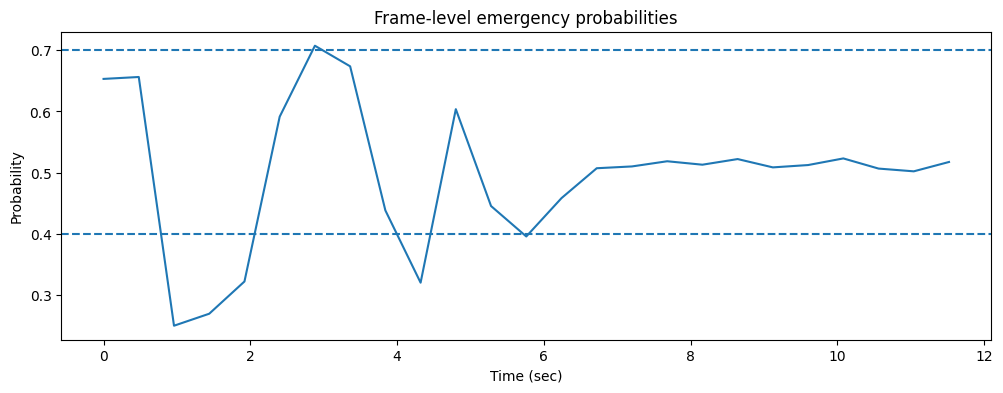

In [81]:
import matplotlib.pyplot as plt

def plot_frame_probs(frame_probs, title="Frame-level emergency probabilities"):
    x = np.arange(len(frame_probs)) * 0.48
    plt.figure(figsize=(12, 4))
    plt.plot(x, frame_probs)
    plt.axhline(0.40, linestyle="--")
    plt.axhline(0.70, linestyle="--")
    plt.xlabel("Time (sec)")
    plt.ylabel("Probability")
    plt.title(title)
    plt.show()

plot_frame_probs(alert_result["frame_probs"])

=== BASIC RESULT ===
{'path': '/kaggle/working/test_audio.wav', 'label_pred': 'normal', 'clip_prob': 0.3045928478240967, 'threshold': 0.4, 'max_frame_prob': 0.5215094685554504, 'mean_frame_prob': 0.3045928478240967, 'num_frames': 34, 'frame_probs': [0.34603172540664673, 0.14310577511787415, 0.3866913914680481, 0.2370602935552597, 0.28267228603363037, 0.21954503655433655, 0.33240556716918945, 0.40900301933288574, 0.0626392737030983, 0.09902483969926834, 0.24074266850948334, 0.12717969715595245, 0.1384507715702057, 0.4373420178890228, 0.3162001669406891, 0.3384507894515991, 0.3575984239578247, 0.39092910289764404, 0.21106292307376862, 0.307950496673584, 0.3598496615886688, 0.18170079588890076, 0.2529372572898865, 0.3259170353412628, 0.3562120795249939, 0.044582951813936234, 0.14705148339271545, 0.35051119327545166, 0.45364513993263245, 0.420059472322464, 0.5186541676521301, 0.5181379318237305, 0.5215094685554504, 0.5213018655776978]}

=== ALERT RESULT ===
{'alert': False, 'reason': 'none

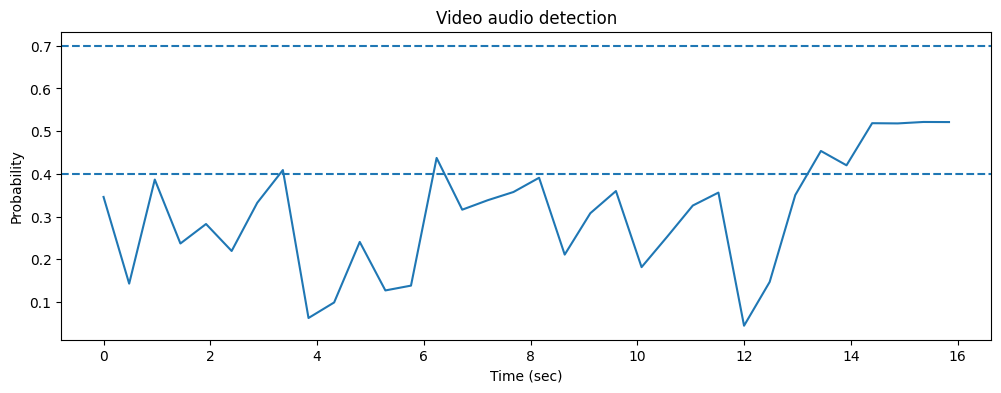

In [82]:
VIDEO_PATH = "/kaggle/input/datasets/sadiamostafa/soundtest3/Screen Recording 2026-03-23 192110.mp4"
OUT_WAV = "/kaggle/working/test_audio.wav"

!ffmpeg -y -i "$VIDEO_PATH" -vn -ac 1 -ar 16000 "$OUT_WAV" > /dev/null 2>&1

result = infer_single_file(OUT_WAV, threshold=0.40)
alert_result = emergency_alert_decision(OUT_WAV)

print("=== BASIC RESULT ===")
print(result)

print("\n=== ALERT RESULT ===")
print(alert_result)

plot_frame_probs(alert_result["frame_probs"], title="Video audio detection")

In [83]:
results = []

for thr in np.arange(0.20, 0.81, 0.02):
    preds = (val_probs >= thr).astype(np.int32)

    tp = np.sum((val_labels == 1) & (preds == 1))
    fp = np.sum((val_labels == 0) & (preds == 1))
    fn = np.sum((val_labels == 1) & (preds == 0))
    tn = np.sum((val_labels == 0) & (preds == 0))

    precision = tp / (tp + fp + 1e-9)
    recall = tp / (tp + fn + 1e-9)
    f1 = 2 * precision * recall / (precision + recall + 1e-9)

    results.append((thr, precision, recall, f1, fp, fn, tp, tn))

best_thr = 0.40
best_f1 = -1

for thr, precision, recall, f1, fp, fn, tp, tn in results:
    if recall >= 0.84 and precision >= 0.75:
        if f1 > best_f1:
            best_f1 = f1
            best_thr = thr

print("Chosen threshold:", best_thr)

for thr, precision, recall, f1, fp, fn, tp, tn in results:
    if abs(thr - best_thr) < 1e-9:
        print(f"precision={precision:.4f}, recall={recall:.4f}, f1={f1:.4f}, fp={fp}, fn={fn}")
        break

Chosen threshold: 0.3999999999999999
precision=0.7996, recall=0.8439, f1=0.8212, fp=103, fn=76


In [84]:
best_thr = 0.40
print("Final deployment threshold:", best_thr)

Final deployment threshold: 0.4


In [85]:
val_frame_preds, val_frame_probs = predict_frame_probs(X_val, threshold=best_thr)

val_labels, val_probs, val_preds = eval_clip_level(
    val_clip_ids,
    val_frame_probs,
    y_val,
    threshold=best_thr
)

print("===== FINAL VAL REPORT =====")
print(classification_report(val_labels, val_preds, target_names=["normal", "emergency"], digits=4))
print(confusion_matrix(val_labels, val_preds))
print("Clip ROC-AUC:", roc_auc_score(val_labels, val_probs))

===== FINAL VAL REPORT =====
              precision    recall  f1-score   support

      normal     0.9283    0.9052    0.9166      1087
   emergency     0.7996    0.8439    0.8212       487

    accuracy                         0.8863      1574
   macro avg     0.8640    0.8746    0.8689      1574
weighted avg     0.8885    0.8863    0.8871      1574

[[984 103]
 [ 76 411]]
Clip ROC-AUC: 0.9408616673813539


In [86]:
test_frame_preds, test_frame_probs = predict_frame_probs(X_test, threshold=best_thr)

test_labels, test_probs, test_preds = eval_clip_level(
    test_clip_ids,
    test_frame_probs,
    y_test,
    threshold=best_thr
)

print("===== FINAL TEST REPORT =====")
print(classification_report(test_labels, test_preds, target_names=["normal", "emergency"], digits=4))
print(confusion_matrix(test_labels, test_preds))
print("Clip ROC-AUC:", roc_auc_score(test_labels, test_probs))

===== FINAL TEST REPORT =====
              precision    recall  f1-score   support

      normal     0.9263    0.9220    0.9241      1090
   emergency     0.8327    0.8410    0.8368       503

    accuracy                         0.8964      1593
   macro avg     0.8795    0.8815    0.8805      1593
weighted avg     0.8967    0.8964    0.8966      1593

[[1005   85]
 [  80  423]]
Clip ROC-AUC: 0.9403742681525525


In [87]:
import json
import os

SAVE_MODEL_PATH = "/kaggle/working/final_audio_model_extratune.keras"
SAVE_CONFIG_PATH = "/kaggle/working/final_audio_config_extratune.json"

model.save(SAVE_MODEL_PATH)

config = {
    "threshold": float(best_thr),
    "sr": int(SR),
    "label_map": {
        "normal": int(LABEL_NORMAL),
        "emergency": int(LABEL_EMERGENCY)
    },
    "realtime_rules": {
        "instant_threshold": 0.60,
        "sustain_threshold": 0.40,
        "window_size": 5,
        "min_count_in_window": 3,
        "consecutive_needed": 2,
        "frame_time_sec": 0.48
    }
}

with open(SAVE_CONFIG_PATH, "w") as f:
    json.dump(config, f, indent=2)

print("Saved model :", SAVE_MODEL_PATH)
print("Saved config:", SAVE_CONFIG_PATH)

Saved model : /kaggle/working/final_audio_model_extratune.keras
Saved config: /kaggle/working/final_audio_config_extratune.json


In [88]:
import json
from tensorflow import keras

LOAD_MODEL_PATH = "/kaggle/working/final_audio_model_extratune.keras"
LOAD_CONFIG_PATH = "/kaggle/working/final_audio_config_extratune.json"

deploy_model = keras.models.load_model(LOAD_MODEL_PATH)

with open(LOAD_CONFIG_PATH, "r") as f:
    deploy_cfg = json.load(f)

best_thr = float(deploy_cfg["threshold"])
SR = int(deploy_cfg["sr"])

print("Loaded deployment model.")
print("Threshold:", best_thr)
print("Sample rate:", SR)

Loaded deployment model.
Threshold: 0.4
Sample rate: 16000


In [89]:
def infer_single_file(path, threshold=None):
    if threshold is None:
        threshold = best_thr

    embs_all = extract_clip_embeddings(path, train_aug=False, n_aug=0)

    if len(embs_all) == 0:
        return {
            "ok": False,
            "error": "Could not extract embeddings from file"
        }

    emb = embs_all[0]
    probs = deploy_model.predict(emb, verbose=0).reshape(-1)

    clip_prob = float(np.mean(probs))
    pred = int(clip_prob >= threshold)

    return {
        "ok": True,
        "path": path,
        "label_pred": "emergency" if pred == 1 else "normal",
        "clip_prob": clip_prob,
        "threshold": float(threshold),
        "max_frame_prob": float(np.max(probs)),
        "mean_frame_prob": float(np.mean(probs)),
        "num_frames": int(len(probs)),
        "frame_probs": probs.tolist()
    }

In [90]:
def emergency_alert_decision(
    path,
    instant_threshold=0.60,
    sustain_threshold=0.40,
    window_size=5,
    min_count_in_window=3,
    consecutive_needed=2,
    frame_time_sec=0.48
):
    out = infer_single_file(path, threshold=best_thr)

    if not out["ok"]:
        return out

    probs = np.array(out["frame_probs"], dtype=np.float32)
    max_prob = float(np.max(probs)) if len(probs) else 0.0
    mean_prob = float(np.mean(probs)) if len(probs) else 0.0
    clip_prob = float(out["clip_prob"])

    # 1) instant alert
    for i, p in enumerate(probs):
        if p >= instant_threshold:
            return {
                "alert": True,
                "alert_at_sec": round(i * frame_time_sec, 2),
                "max_prob": max_prob,
                "mean_prob": mean_prob,
                "clip_prob": clip_prob,
                "num_frames": int(len(probs)),
                "reason": "instant_high_confidence"
            }

    # 2) consecutive medium-confidence alert
    consec = 0
    for i, p in enumerate(probs):
        if p >= sustain_threshold:
            consec += 1
            if consec >= consecutive_needed:
                return {
                    "alert": True,
                    "alert_at_sec": round(i * frame_time_sec, 2),
                    "max_prob": max_prob,
                    "mean_prob": mean_prob,
                    "clip_prob": clip_prob,
                    "num_frames": int(len(probs)),
                    "reason": "consecutive_medium_confidence"
                }
        else:
            consec = 0

    # 3) window-based sustained alert
    flags = (probs >= sustain_threshold).astype(np.int32)
    for i in range(len(flags)):
        left = max(0, i - window_size + 1)
        cnt = int(np.sum(flags[left:i+1]))
        if cnt >= min_count_in_window:
            return {
                "alert": True,
                "alert_at_sec": round(i * frame_time_sec, 2),
                "max_prob": max_prob,
                "mean_prob": mean_prob,
                "clip_prob": clip_prob,
                "num_frames": int(len(probs)),
                "reason": "window_sustained_confidence"
            }

    return {
        "alert": False,
        "alert_at_sec": None,
        "max_prob": max_prob,
        "mean_prob": mean_prob,
        "clip_prob": clip_prob,
        "num_frames": int(len(probs)),
        "reason": "none"
    }